In [1]:
# --- TASK 3: Supervised Learning with Logistic Regression ---
# Predicting Diabetes (Binary Classification)

# --- STEP 1: Import Libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [2]:
# --- STEP 2: Load dataset ---
CSV_PATH = "Downloads/Diabetes.csv"
df = pd.read_csv(CSV_PATH)
print("\nDataset Loaded Successfully\n")
print(df.head())




Dataset Loaded Successfully

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- Missing Values ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesP

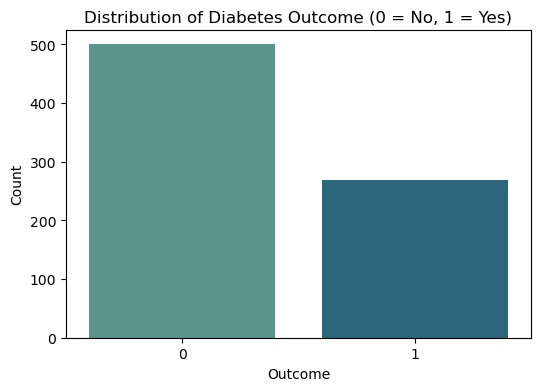

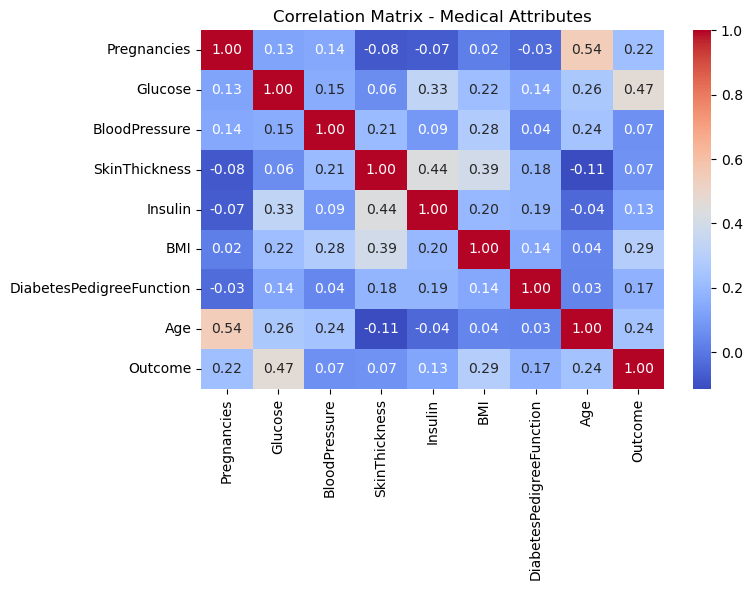

In [5]:
# --- STEP 3: Basic EDA ---
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
print(df.describe())

# --- Class Balance Visualization ---
plt.figure(figsize=(6,4))
sns.countplot(
    x='Outcome',
    data=df,
    hue='Outcome',        
    palette='crest',
    legend=False
)
plt.title("Distribution of Diabetes Outcome (0 = No, 1 = Yes)")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

# --- Correlation Heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Medical Attributes")
plt.tight_layout()
plt.show()


In [6]:
# --- STEP 4: Data Preprocessing ---
X = df.drop(columns='Outcome')
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# --- STEP 5: Logistic Regression with different train-test splits ---
splits = [0.2, 0.25, 0.3]
results = []

for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=split, random_state=42)

    # Try both L1 and L2 regularization
    for penalty in ['l1', 'l2']:
        solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
        model = LogisticRegression(penalty=penalty, solver=solver, max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append({
            'Test Size': split,
            'Penalty': penalty,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1
        })

results_df = pd.DataFrame(results)
print("\n--- Model Performance Across Different Splits & Regularization ---")
print(results_df.round(4))



--- Model Performance Across Different Splits & Regularization ---
   Test Size Penalty  Accuracy  Precision  Recall  F1 Score
0       0.20      l1    0.7468     0.6379  0.6727    0.6549
1       0.20      l2    0.7532     0.6491  0.6727    0.6607
2       0.25      l1    0.7188     0.6056  0.6232    0.6143
3       0.25      l2    0.7292     0.6164  0.6522    0.6338
4       0.30      l1    0.7273     0.6076  0.6000    0.6038
5       0.30      l2    0.7359     0.6173  0.6250    0.6211



--- Classification Report (Final Model) ---
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       123
           1       0.62      0.65      0.63        69

    accuracy                           0.73       192
   macro avg       0.71      0.71      0.71       192
weighted avg       0.73      0.73      0.73       192



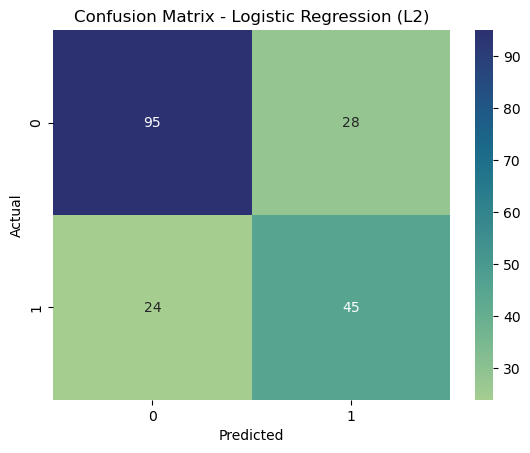

In [11]:
# --- STEP 6: Final Model (best parameters) ---
best_model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\n--- Classification Report (Final Model) ---")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='crest')
plt.title("Confusion Matrix - Logistic Regression (L2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

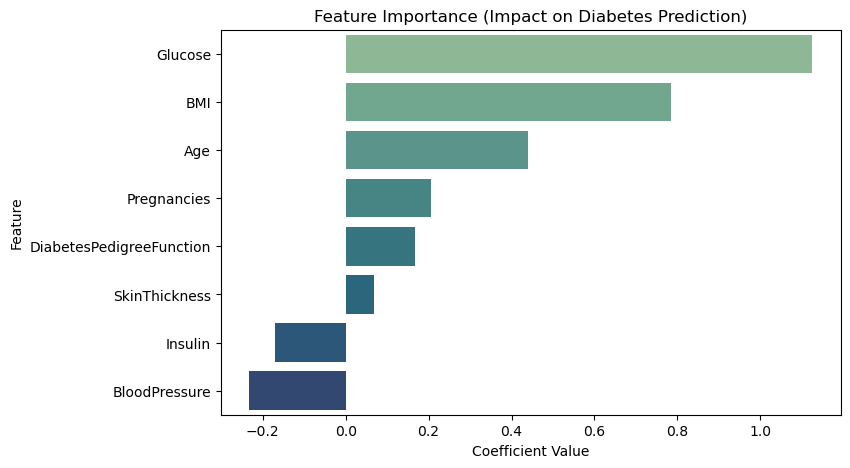


--- Feature Coefficients ---
                    Feature  Coefficient
1                   Glucose     1.126035
5                       BMI     0.784752
7                       Age     0.438639
0               Pregnancies     0.205527
6  DiabetesPedigreeFunction     0.167675
3             SkinThickness     0.068729
4                   Insulin    -0.171595
2             BloodPressure    -0.233674


In [13]:
# --- STEP 7: Coefficient Interpretation ---
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients,
    hue='Feature',        
    palette='crest',
    legend=False         
)
plt.title("Feature Importance (Impact on Diabetes Prediction)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

print("\n--- Feature Coefficients ---")
print(coefficients)


In [15]:
# --- STEP 8: Findings & Conclusion ---
print("\n--- Findings ---")
print("• Glucose and BMI have the strongest positive influence on diabetes likelihood.")
print("• BloodPressure and Age also contribute moderately.")
print("• L2 regularization provided better generalization than L1 in this dataset.")
print("• Performance remained stable across different train-test splits (approx. 75–80% accuracy).")

print("\n--- Conclusion ---")
print("The logistic regression model successfully classifies diabetic vs. non-diabetic patients.")
print("Key predictors include Glucose, BMI, and Age. Further improvements could involve feature engineering,")
print("handling zero values in medical fields like Insulin or SkinThickness, and testing advanced models like Random Forests or XGBoost.")



--- Findings ---
• Glucose and BMI have the strongest positive influence on diabetes likelihood.
• BloodPressure and Age also contribute moderately.
• L2 regularization provided better generalization than L1 in this dataset.
• Performance remained stable across different train-test splits (approx. 75–80% accuracy).

--- Conclusion ---
The logistic regression model successfully classifies diabetic vs. non-diabetic patients.
Key predictors include Glucose, BMI, and Age. Further improvements could involve feature engineering,
handling zero values in medical fields like Insulin or SkinThickness, and testing advanced models like Random Forests or XGBoost.
